<a href="https://colab.research.google.com/github/PeroronShine/education_fefu_2/blob/main/AI_prog/ML_lab8_SpaceshipTitanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = pd.read_csv('train.csv')

print("Первые 5 строк данных:")
print(df.head())

print(f"\nРазмер датасета: {df.shape}")
print("\nПропущенные значения:")
print(df.isnull().sum())

Первые 5 строк данных:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        Fals

In [ ]:
y = df['Transported'].astype(bool)

X = df.drop(columns=['Transported', 'PassengerId', 'Name', 'Cabin'])  # Удаляем идентификаторы и сложные поля

X['Age'] = X['Age'].fillna(X['Age'].median())
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    X[col] = X[col].fillna(0)

le_planet = LabelEncoder()
le_destination = LabelEncoder()

X['HomePlanet'] = le_planet.fit_transform(X['HomePlanet'].astype(str))
X['Destination'] = le_destination.fit_transform(X['Destination'].astype(str))

X['CryoSleep'] = X['CryoSleep'].map({True: 1, False: 0})
X['VIP'] = X['VIP'].map({True: 1, False: 0})



Точность модели: 0.7855

Отчёт по классификации:
              precision    recall  f1-score   support

       False       0.78      0.79      0.79       863
        True       0.79      0.78      0.79       876

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



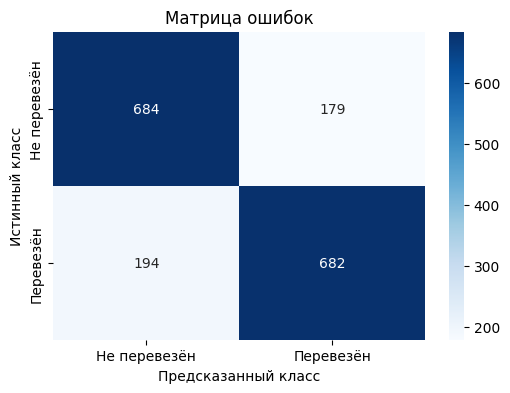


Важность признаков:
        feature  importance
3           Age    0.167840
8           Spa    0.138421
5   RoomService    0.135322
9        VRDeck    0.126066
1     CryoSleep    0.117438
6     FoodCourt    0.116337
7  ShoppingMall    0.096776
0    HomePlanet    0.063832
2   Destination    0.029342
4           VIP    0.008627


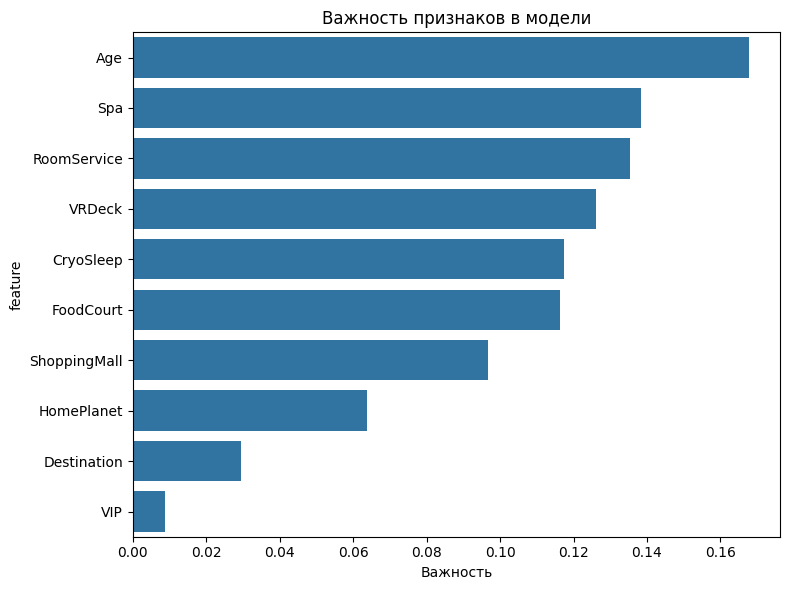

In [ ]:
X = X.fillna(-1)  # -1 как метка "неизвестно"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=170, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nТочность модели: {acc:.4f}")
print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Не перевезён', 'Перевезён'], yticklabels=['Не перевезён', 'Перевезён'])
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nВажность признаков:")
print(feature_importance_df)

# Визуализация важности
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature')
plt.title('Важность признаков в модели')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

--------------------------------


Первые 5 строк данных:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        Fals

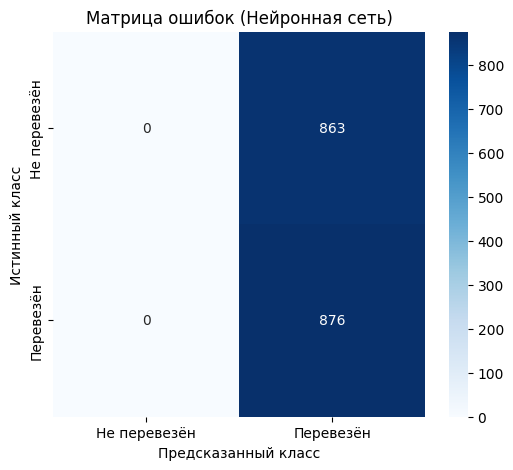

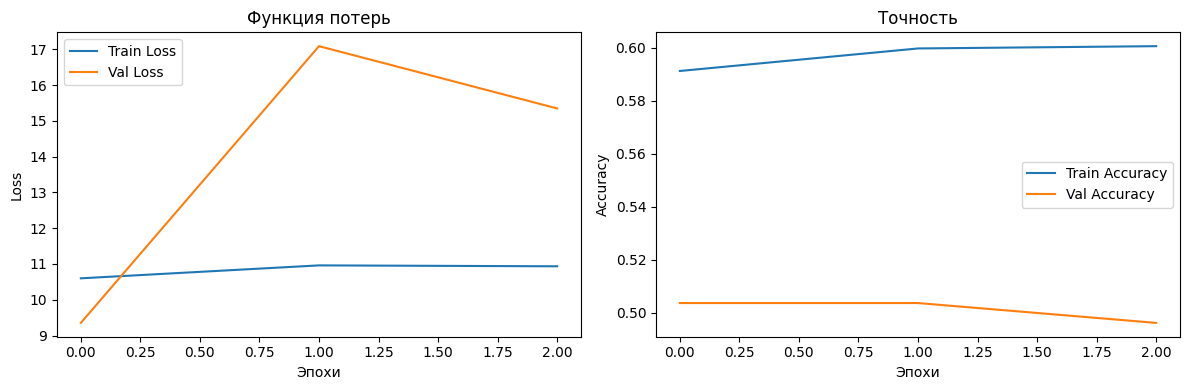

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('train.csv')

print("Первые 5 строк данных:")
print(df.head())

print(f"\nРазмер датасета: {df.shape}")
print("\nПропущенные значения:")
print(df.isnull().sum())

y = df['Transported'].astype(bool)

X = df.drop(columns=['Transported', 'PassengerId', 'Name', 'Cabin'])  # Удаляем идентификаторы и сложные поля

X['Age'] = X['Age'].fillna(X['Age'].median())
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    X[col] = X[col].fillna(0)

le_planet = LabelEncoder()
le_destination = LabelEncoder()

X['HomePlanet'] = le_planet.fit_transform(X['HomePlanet'].astype(str))
X['Destination'] = le_destination.fit_transform(X['Destination'].astype(str))

X['CryoSleep'] = X['CryoSleep'].map({True: 1, False: 0})
X['VIP'] = X['VIP'].map({True: 1, False: 0})

X = X.fillna(-1)

print("\n" + "="*50)
print("СОЗДАНИЕ НАИХУДШЕЙ НЕЙРОННОЙ СЕТИ")
print("="*50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

model_worst = Sequential([
    Dense(1, activation='tanh', input_shape=(X_train.shape[1],)),  # Только 1 нейрон

    Dense(1, activation='sigmoid')
])

model_worst.compile(
    optimizer=SGD(learning_rate=100.0),  # lr = 100
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_worst = EarlyStopping(
    monitor='val_loss',
    patience=2,  # останавливаемся на 2 эпохе
    restore_best_weights=True,
    verbose=1
)


history_worst = model_worst.fit(
    X_train, y_train,
    epochs=100,  # Но ранняя остановка остановит на 2-й эпохе
    batch_size=128,  # Большой батч → медленное обучение
    validation_data=(X_test, y_test),
    callbacks=[early_stop_worst],
    verbose=1
)

test_loss_worst, test_acc_worst = model_worst.evaluate(X_test, y_test, verbose=0)
print(f"\nТочность нейронной сети на тесте: {test_acc_worst:.4f}")

y_pred_prob_worst = model_worst.predict(X_test)
y_pred_worst = (y_pred_prob_worst > 0.5).flatten()

print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_worst))

cm_worst = confusion_matrix(y_test, y_pred_worst)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Blues', xticklabels=['Не перевезён', 'Перевезён'], yticklabels=['Не перевезён', 'Перевезён'])
plt.title('Матрица ошибок (Нейронная сеть)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_worst.history['loss'], label='Train Loss')
plt.plot(history_worst.history['val_loss'], label='Val Loss')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_worst.history['accuracy'], label='Train Accuracy')
plt.plot(history_worst.history['val_accuracy'], label='Val Accuracy')
plt.title('Точность')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [85]:
y = df['Transported'].astype(str).map({'True': True, 'False': False})
y = y.fillna(False).astype(bool)


X = df.drop(columns=['Transported', 'PassengerId', 'Name', 'Cabin'])


X['Age'] = X['Age'].fillna(X['Age'].median())
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    X[col] = X[col].fillna(0)


X['HomePlanet'] = X['HomePlanet'].astype(str).fillna('Unknown')
X['Destination'] = X['Destination'].astype(str).fillna('Unknown')

le_planet = LabelEncoder()
le_destination = LabelEncoder()
X['HomePlanet'] = le_planet.fit_transform(X['HomePlanet'])
X['Destination'] = le_destination.fit_transform(X['Destination'])
X['CryoSleep'] = X['CryoSleep'].map({True: 1, False: 0}).fillna(0)
X['VIP'] = X['VIP'].map({True: 1, False: 0}).fillna(0)


X = X.fillna(-1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)
y_train_inverted = ~y_train

model_worst = RandomForestClassifier(
    n_estimators=6,
    max_depth=10,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42,
    bootstrap=True
)

model_worst.fit(X_train, y_train_inverted)
y_pred_worst = model_worst.predict(X_test)


test_acc_worst = accuracy_score(y_test, y_pred_worst)
print(f"\nТочность Random Forest на тесте: {test_acc_worst:.4f}")

print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_worst))


Точность Random Forest на тесте: 0.2011

Отчёт по классификации:
              precision    recall  f1-score   support

       False       0.22      0.23      0.22       432
        True       0.18      0.17      0.18       438

    accuracy                           0.20       870
   macro avg       0.20      0.20      0.20       870
weighted avg       0.20      0.20      0.20       870




Отчёт по классификации:
              precision    recall  f1-score   support

       False       0.22      0.24      0.23       432
        True       0.18      0.16      0.17       438

    accuracy                           0.20       870
   macro avg       0.20      0.20      0.20       870
weighted avg       0.20      0.20      0.20       870



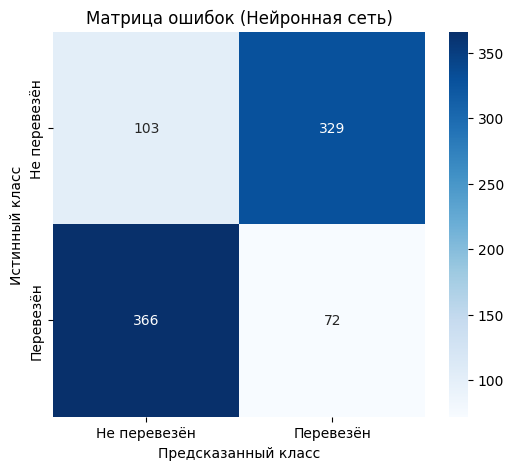

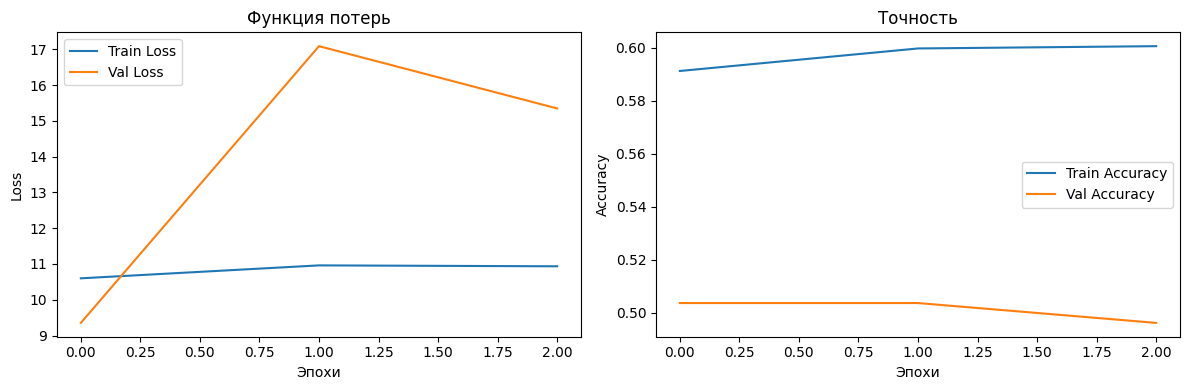

In [84]:
print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_worst))

cm_worst = confusion_matrix(y_test, y_pred_worst)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Blues', xticklabels=['Не перевезён', 'Перевезён'], yticklabels=['Не перевезён', 'Перевезён'])
plt.title('Матрица ошибок (Нейронная сеть)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_worst.history['loss'], label='Train Loss')
plt.plot(history_worst.history['val_loss'], label='Val Loss')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_worst.history['accuracy'], label='Train Accuracy')
plt.plot(history_worst.history['val_accuracy'], label='Val Accuracy')
plt.title('Точность')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()